# Transfer Learning CIFAR10

* Train a simple convnet on the CIFAR dataset the first 5 output classes [0..4].
* Freeze convolutional layers and fine-tune dense layers for the last 5 ouput classes [5..9].


In [1]:
# Initialize the random number generator
import random
random.seed(0)

### 1. Import CIFAR10 data and create 2 datasets with one dataset having classes from 0 to 4 and other having classes from 5 to 9 

In [2]:
import numpy as np
import tensorflow as tf
from keras.backend import backend
from keras.datasets import cifar10

/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:519: FutureWa

In [3]:
# the data, shuffled and split between train and test sets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

Label: [9]


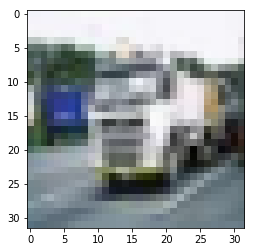

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
print("Label: {}".format(y_train[1000]))
plt.imshow(X_train[1000])

In [5]:
X_train0_4 = np.asarray([X_train[key] for (key, label) in enumerate(y_train) if int(label) >= 0 and int(label) <= 4])
X_train5_9 = np.asarray([X_train[key] for (key, label) in enumerate(y_train) if int(label) >= 5 and int(label) <= 9])

X_test0_4 = np.asarray([X_test[key] for (key, label) in enumerate(y_test) if int(label) >= 0 and int(label) <= 4])
X_test5_9 = np.asarray([X_test[key] for (key, label) in enumerate(y_test) if int(label) >= 5 and int(label) <= 9])

In [6]:
y_train0_4 = np.asarray([y_train[key] for (key, label) in enumerate(y_train) if int(label) >= 0 and int(label) <= 4])
y_train5_9 = np.asarray([y_train[key] for (key, label) in enumerate(y_train) if int(label) >= 5 and int(label) <= 9])

y_test0_4 = np.asarray([y_test[key] for (key, label) in enumerate(y_test) if int(label) >= 0 and int(label) <= 4])
y_test5_9 = np.asarray([y_test[key] for (key, label) in enumerate(y_test) if int(label) >= 5 and int(label) <= 9])

In [7]:
(X_train.shape, y_train.shape), (X_test.shape, y_test.shape) 

(((50000, 32, 32, 3), (50000, 1)), ((10000, 32, 32, 3), (10000, 1)))

In [8]:
(X_train0_4.shape, y_train0_4.shape), (X_test0_4.shape, y_test0_4.shape) 

(((25000, 32, 32, 3), (25000, 1)), ((5000, 32, 32, 3), (5000, 1)))

In [9]:
(X_train5_9.shape, y_train5_9.shape), (X_test5_9.shape, y_test5_9.shape) 

(((25000, 32, 32, 3), (25000, 1)), ((5000, 32, 32, 3), (5000, 1)))

In [10]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [11]:
np.unique(y_test0_4),  np.unique(y_train0_4)

(array([0, 1, 2, 3, 4]), array([0, 1, 2, 3, 4], dtype=uint8))

In [12]:
np.unique(y_test5_9), np.unique(y_train5_9)

(array([5, 6, 7, 8, 9]), array([5, 6, 7, 8, 9], dtype=uint8))

In [13]:
print("Shape of X_train = ", X_train0_4.shape)
print("number of images in X_train = ", X_train0_4.shape[0])
print("number of images in X_test = ", X_test0_4.shape[0])

Shape of X_train =  (25000, 32, 32, 3)
number of images in X_train =  25000
number of images in X_test =  5000


### 2. Use One-hot encoding to divide y_train and y_test into required no of output classes

In [14]:
class_names_len0_4 = len(np.unique(y_train0_4))
y_train0_4 = tf.keras.utils.to_categorical(y_train0_4, num_classes=class_names_len0_4)
y_test0_4 = tf.keras.utils.to_categorical(y_test0_4, num_classes=class_names_len0_4)
y_test0_4.shape

(5000, 5)

In [15]:
X_train0_4 = X_train0_4.astype("float32")/255.0
X_test0_4 = X_test0_4.astype("float32")/255.0

### 3. Build a sequential neural network model which can classify the classes 0 to 4 of CIFAR10 dataset with at least 80% accuracy on test data

In [16]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(512, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(class_names_len0_4, activation='softmax'))

# initiate RMSprop optimizer
opt = tf.keras.optimizers.RMSprop(learning_rate=0.001, decay=1e-6)

# Let's train the model using RMSprop
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [17]:
epochs=20
batch_size = 128

model.fit(X_train0_4, y_train0_4, validation_data=(X_test0_4, y_test0_4), batch_size=batch_size, epochs=epochs)

Train on 25000 samples, validate on 5000 samples
Epoch 1/20
25000/25000 [==============================] - 5s 204us/sample - loss: 1.3182 - acc: 0.4540 - val_loss: 1.1105 - val_acc: 0.5404
Epoch 2/20
25000/25000 [==============================] - 3s 127us/sample - loss: 0.9842 - acc: 0.6072 - val_loss: 0.8742 - val_acc: 0.6638
Epoch 3/20
25000/25000 [==============================] - 3s 130us/sample - loss: 0.8384 - acc: 0.6756 - val_loss: 0.7256 - val_acc: 0.7276
Epoch 4/20
25000/25000 [==============================] - 3s 126us/sample - loss: 0.7443 - acc: 0.7126 - val_loss: 0.6904 - val_acc: 0.7334
Epoch 5/20
25000/25000 [==============================] - 3s 132us/sample - loss: 0.6757 - acc: 0.7455 - val_loss: 0.9911 - val_acc: 0.6428
Epoch 6/20
25000/25000 [==============================] - 3s 130us/sample - loss: 0.6261 - acc: 0.7650 - val_loss: 0.7251 - val_acc: 0.7184
Epoch 7/20
25000/25000 [==============================] - 3s 127us/sample - loss: 0.5677 - acc: 0.7868 - val_lo

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              multiple                  896       
_________________________________________________________________
conv2d_1 (Conv2D)            multiple                  9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) multiple                  0         
_________________________________________________________________
dropout (Dropout)            multiple                  0         
_________________________________________________________________
conv2d_2 (Conv2D)            multiple                  18496     
_________________________________________________________________
conv2d_3 (Conv2D)            multiple                  36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 multiple                  0

In [19]:
train_acc = model.evaluate(X_train0_4, y_train0_4)
test_acc = model.evaluate(X_test0_4, y_test0_4)
train_acc, test_acc

5000/5000 [==============================] - 0s 83us/sample - loss: 0.5541 - acc: 0.8062


([0.30470864283561705, 0.89164], [0.5541321820259094, 0.8062])

In [20]:
print("Model Train accuracy = ", train_acc[1])
print("Model Test accuracy = ", test_acc[1])

Model Train accuracy =  0.89164
Model Test accuracy =  0.8062


### 4. In the model which was built above (for classification of classes 0-4 in CIFAR10), make only the dense layers to be trainable and conv layers to be non-trainable

In [21]:
#Set pre-trained model layers to not trainable
for layer in model.layers:
    if not isinstance(layer, tf.keras.layers.Dense):
        layer.trainable = False
    print(layer, layer.trainable)

<tensorflow.python.keras.layers.convolutional.Conv2D object at 0x7fae33cd4c18> False
<tensorflow.python.keras.layers.convolutional.Conv2D object at 0x7fae33cd4f28> False
<tensorflow.python.keras.layers.pooling.MaxPooling2D object at 0x7fae33cbe438> False
<tensorflow.python.keras.layers.core.Dropout object at 0x7fae33cbe8d0> False
<tensorflow.python.keras.layers.convolutional.Conv2D object at 0x7fae33cbeb00> False
<tensorflow.python.keras.layers.convolutional.Conv2D object at 0x7fae33cbec50> False
<tensorflow.python.keras.layers.pooling.MaxPooling2D object at 0x7fae33aa30f0> False
<tensorflow.python.keras.layers.core.Dropout object at 0x7fae33cbe0f0> False
<tensorflow.python.keras.layers.core.Flatten object at 0x7fae33cbe0b8> False
<tensorflow.python.keras.layers.core.Dense object at 0x7fae33aa38d0> True
<tensorflow.python.keras.layers.core.Dropout object at 0x7fae33aa3a20> False
<tensorflow.python.keras.layers.core.Dense object at 0x7fae33aa3cf8> True


### 5. Utilize the the model trained on CIFAR 10 (classes 0 to 4) to classify the classes 5 to 9 of CIFAR 10  (Use Transfer Learning) <br>
Achieve an accuracy of more than 85% on test data

In [22]:
# Let's train the model using RMSprop
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

In [23]:
#Prepare second dataset
class_names_len5_9 = len(np.unique(y_train5_9))
y_train5_9 = y_train5_9 - 5
y_test5_9 = y_test5_9 - 5

In [24]:
X_train5_9 = X_train5_9.astype("float32")/255.0
X_test5_9 = X_test5_9.astype("float32")/255.0

In [25]:
print("Shape of X_train = ", X_train5_9.shape)
print("number of images in X_train = ", X_train5_9.shape[0])
print("number of images in X_test = ", X_test5_9.shape[0])

Shape of X_train =  (25000, 32, 32, 3)
number of images in X_train =  25000
number of images in X_test =  5000


In [26]:
class_names_len5_9 = len(np.unique(y_train5_9))
y_train5_9 = tf.keras.utils.to_categorical(y_train5_9, num_classes=class_names_len5_9)
y_test5_9 = tf.keras.utils.to_categorical(y_test5_9, num_classes=class_names_len5_9)
y_test5_9.shape

(5000, 5)

In [27]:
epochs=20
batch_size = 128

model.fit(X_train5_9, y_train5_9, validation_data=(X_test5_9, y_test5_9), batch_size=batch_size, epochs=epochs)

Train on 25000 samples, validate on 5000 samples
Epoch 1/20
25000/25000 [==============================] - 2s 82us/sample - loss: 1.0030 - acc: 0.6448 - val_loss: 0.5423 - val_acc: 0.8012
Epoch 2/20
25000/25000 [==============================] - 2s 73us/sample - loss: 0.5794 - acc: 0.7922 - val_loss: 0.4660 - val_acc: 0.8364
Epoch 3/20
25000/25000 [==============================] - 2s 74us/sample - loss: 0.5120 - acc: 0.8194 - val_loss: 0.4333 - val_acc: 0.8474
Epoch 4/20
25000/25000 [==============================] - 2s 75us/sample - loss: 0.4708 - acc: 0.8321 - val_loss: 0.4147 - val_acc: 0.8528
Epoch 5/20
25000/25000 [==============================] - 2s 76us/sample - loss: 0.4478 - acc: 0.8423 - val_loss: 0.4023 - val_acc: 0.8566
Epoch 6/20
25000/25000 [==============================] - 2s 78us/sample - loss: 0.4265 - acc: 0.8503 - val_loss: 0.3909 - val_acc: 0.8640
Epoch 7/20
25000/25000 [==============================] - 2s 76us/sample - loss: 0.4059 - acc: 0.8580 - val_loss: 0.3

In [28]:
train_acc = model.evaluate(X_train5_9, y_train5_9)
test_acc = model.evaluate(X_test5_9, y_test5_9)
train_acc, test_acc

5000/5000 [==============================] - 0s 70us/sample - loss: 0.3669 - acc: 0.8854


([0.13624482018828393, 0.95864], [0.3669371509552002, 0.8854])

In [29]:
print("Model Train accuracy = ", train_acc[1])
print("Model Test accuracy = ", test_acc[1])

Model Train accuracy =  0.95864
Model Test accuracy =  0.8854


# Text classification using TF-IDF

### 6. Load the dataset from sklearn.datasets

In [30]:
from sklearn.datasets import fetch_20newsgroups

In [31]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

### 7. Training data

In [32]:
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

### 8. Test data

In [33]:
twenty_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

###  a.  You can access the values for the target variable using .target attribute 
###  b. You can access the name of the class in the target variable with .target_names


In [34]:
twenty_train.target

array([1, 1, 3, ..., 2, 2, 2])

In [35]:
twenty_train.target_names

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [36]:
twenty_train.data[0:5]

['From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n',
 "From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\nSubject: help: Splitting a trimming region along a mesh \nOrganization: University Of Kentucky, Dept. of Math Sciences\nLines: 28\n\n\n\n\tHi,\n\n\tI have a problem, I hope some of the 'gurus' can help me solve.\n\n\tBackground of the probl

### 9.  Now with dependent and independent data available for both train and test datasets, using TfidfVectorizer fit and transform the training data and test data and get the tfidf features for both

In [37]:
# import all the python packages need for this problem solving
import pandas as pd
import numpy as np
import scipy as sp

# import CountVectorizer and TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [38]:
# TfidfVectorizer on train data
vect = TfidfVectorizer()
pd.DataFrame(vect.fit_transform(twenty_train.target_names).toarray(), columns=vect.get_feature_names())

,alt,atheism,christian,comp,graphics,med,religion,sci,soc
0,0.707107,0.707107,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
1,0.000000,0.000000,0.00000,0.707107,0.707107,0.000000,0.00000,0.000000,0.00000
2,0.000000,0.000000,0.00000,0.000000,0.000000,0.707107,0.00000,0.707107,0.00000
3,0.000000,0.000000,0.57735,0.000000,0.000000,0.000000,0.57735,0.000000,0.57735


In [39]:
# TfidfVectorizer on test data
vect = TfidfVectorizer()
pd.DataFrame(vect.fit_transform(twenty_test.target_names).toarray(), columns=vect.get_feature_names())

,alt,atheism,christian,comp,graphics,med,religion,sci,soc
0,0.707107,0.707107,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
1,0.000000,0.000000,0.00000,0.707107,0.707107,0.000000,0.00000,0.000000,0.00000
2,0.000000,0.000000,0.00000,0.000000,0.000000,0.707107,0.00000,0.707107,0.00000
3,0.000000,0.000000,0.57735,0.000000,0.000000,0.000000,0.57735,0.000000,0.57735


In [40]:
# Term Frequency on train data
vect = CountVectorizer()
tf_train = pd.DataFrame(vect.fit_transform(twenty_train.target_names).toarray(), columns=vect.get_feature_names())
tf_train

,alt,atheism,christian,comp,graphics,med,religion,sci,soc
0,1,1,0,0,0,0,0,0,0
1,0,0,0,1,1,0,0,0,0
2,0,0,0,0,0,1,0,1,0
3,0,0,1,0,0,0,1,0,1


In [41]:
# print the frequency of the tokens on train dataset
vect = CountVectorizer()
df_train = vect.fit_transform(twenty_train.target_names).toarray().sum(axis=0)
pd.DataFrame(df_train.reshape(1, 9), columns=vect.get_feature_names())

,alt,atheism,christian,comp,graphics,med,religion,sci,soc
0,1,1,1,1,1,1,1,1,1


In [42]:
# Term Frequency for test set
vect = CountVectorizer()
tf_test = pd.DataFrame(vect.fit_transform(twenty_test.target_names).toarray(), columns=vect.get_feature_names())
tf_test

,alt,atheism,christian,comp,graphics,med,religion,sci,soc
0,1,1,0,0,0,0,0,0,0
1,0,0,0,1,1,0,0,0,0
2,0,0,0,0,0,1,0,1,0
3,0,0,1,0,0,0,1,0,1


In [43]:
# print the frequency of the tokens on test dataset
vect = CountVectorizer()
df_test = vect.fit_transform(twenty_test.target_names).toarray().sum(axis=0)
pd.DataFrame(df_train.reshape(1, 9), columns=vect.get_feature_names())

,alt,atheism,christian,comp,graphics,med,religion,sci,soc
0,1,1,1,1,1,1,1,1,1


### 10. Use logisticRegression with tfidf features as input and targets as output and train the model and report the train and test accuracy score

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [45]:
# TFIDF vectorization on train and test dataset and create dtm
vect = TfidfVectorizer()
vect.fit(twenty_train.data)
x_train_dtm = vect.transform(twenty_train.data)
x_test_dtm = vect.transform(twenty_test.data)

In [46]:
# Create Logistic regression model and train using train data
logistic_regress = LogisticRegression()
logistic_regress.fit(x_train_dtm, twenty_train.target)

/home/siju/.local/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/home/siju/.local/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)

In [47]:
# Test using test data and print accuracy score
y_pred_class = logistic_regress.predict(x_test_dtm)
acc = metrics.accuracy_score(twenty_test.target, y_pred_class)*100
print("Test accuracy:", acc)

Test accuracy: 88.68175765645806
